# RANSAC Empirical Analysis
**CS5008 Final Project — Arsh Singh**

This notebook runs all three experiments and generates plots for the report.

---
## 1. Setup and Imports

In [88]:
import sys
import random
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# plot style
plt.rcParams.update({
    'figure.dpi': 150,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})

# output directory for saved figures
import os
FIG_DIR = '../figures'
os.makedirs(FIG_DIR, exist_ok=True)
DATA_DIR = 'results'
os.makedirs(DATA_DIR, exist_ok=True)

# Column rename dictionary shared across all three experiments.
# Apply with: df.rename(columns=COL_NAMES, inplace=True)

COL_NAMES = {
    'index':       'Run Index',
    'n':           'Total Points (N)',
    'epsilon':     'Outlier Fraction (ε)',
    'd':           'Expected Inliers (d)',
    'm':           'Model Parameters (m)',
    'k':           'Iterations Used (k)',
    'k_budget':    'Iteration Budget (k)',
    'k_theory':    'Iterations Required by Theory',
    't':           'Inlier Threshold (t)',
    'pr':          'Bias Probability (pr)',
    'bias_type':   'Bias Type',
    'repeat':      'Repeat Number',
    'time_mu_s':   'Wall-Clock Time (μs)',
    'model_error': 'Model Error (Euclidean)',
}
print('Setup complete.')

Setup complete.


---
## Experiment 01: Does wall-clock time grow linearly with k?
 *     Fixes epsilon = 0.5. Varies k from 10 to 500 in steps of 10.
 *     Runs for linear (m = 2) and quadratic (m = 3) models.
 *     N_TOTAL = 1000 is fixed throughout.
 *     Repeats N_REPEATS times per condition.

In [93]:
df01 = pd.read_csv(f"{DATA_DIR}/exp01.csv")
df01.rename(columns=COL_NAMES, inplace=True)
df01.head()

,Run Index,Total Points (N),Outlier Fraction (ε),Expected Inliers (d),Model Parameters (m),Iterations Used (k),Inlier Threshold (t),Repeat Number,Wall-Clock Time (μs),Model Error (Euclidean)
0,0,1000,0.5,500,2,10,0.9539,0,214.0,0.129987
1,1,1000,0.5,500,2,10,1.0090,1,232.0,1.111417
2,2,1000,0.5,500,2,10,1.0155,2,230.0,0.343333
3,3,1000,0.5,500,2,10,1.0327,3,247.0,0.538899
4,4,1000,0.5,500,2,10,0.9710,4,225.0,0.832920


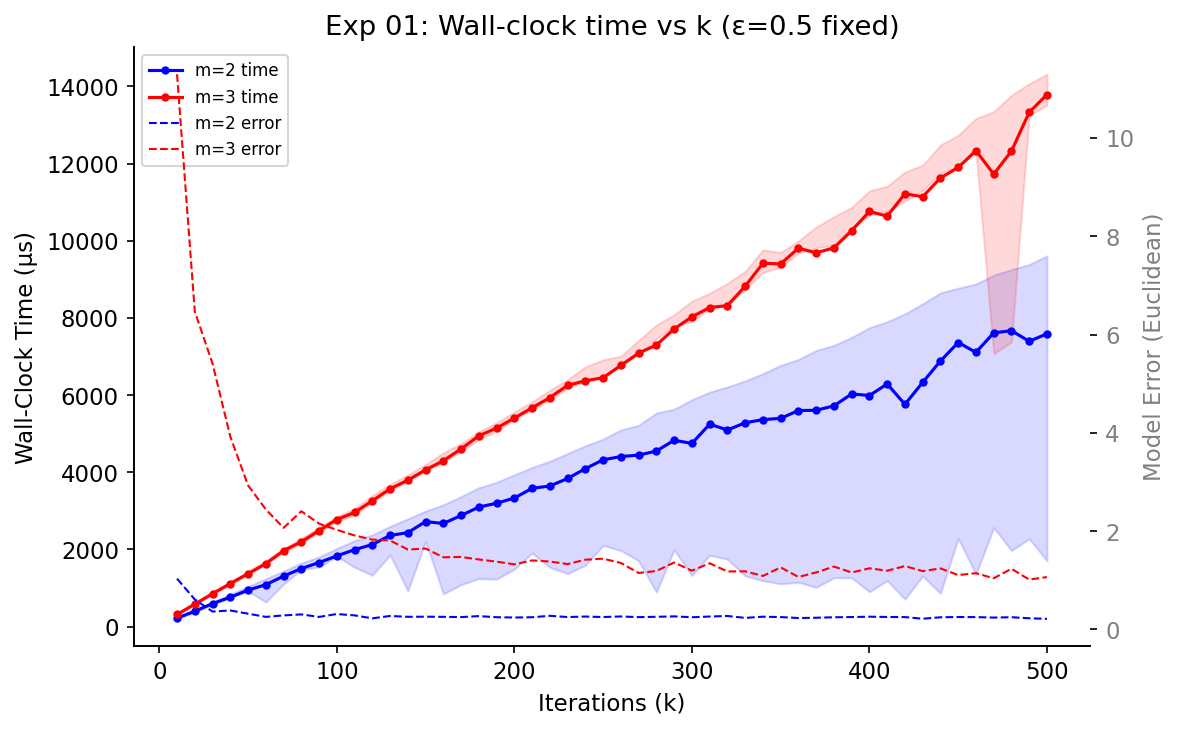

In [96]:
fig, ax1 = plt.subplots(figsize=(8, 5))
ax2 = ax1.twinx()

for m, color in [(2, "blue"), (3, "red")]:
    sub = df01[df01["Model Parameters (m)"] == m]
    grp = sub.groupby("Iterations Used (k)")["Wall-Clock Time (μs)"]
    means = grp.mean()
    lower = grp.quantile(0.10)
    upper = grp.quantile(0.90)

    ax1.plot(means.index, means.values,
             color=color, marker="o", markersize=3, label=f"m={m} time")
    ax1.fill_between(means.index, lower, upper, alpha=0.15, color=color)

    grp2 = sub.groupby("Iterations Used (k)")["Model Error (Euclidean)"]
    ax2.plot(grp2.mean().index, grp2.mean().values,
             color=color, linestyle="--", linewidth=1, label=f"m={m} error")

ax1.set_xlabel("Iterations (k)")
ax1.set_ylabel("Wall-Clock Time (μs)")
ax2.set_ylabel("Model Error (Euclidean)", color="grey")
ax2.tick_params(axis="y", labelcolor="grey")
ax1.set_title("Exp 01: Wall-clock time vs k (ε=0.5 fixed)")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=8)

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/exp01_time_vs_k.png", dpi=150)
plt.show()

## Experiment 0_2: Does wall-clock time grow with epsilon for fixed k?
 *     Fixes k at the value computed for epsilon = 0.5. Varies epsilon
 *     from 0.05 to 0.95 in steps of 0.05. Runs for linear (m = 2) and
 *     quadratic (m = 3) models. N_TOTAL = 1000 is fixed throughout.
 *     Repeats N_REPEATS times per condition.

In [103]:
df02 = pd.read_csv(f"{DATA_DIR}/exp02.csv")
df02.rename(columns=COL_NAMES, inplace=True)
df02.head()

,Run Index,Total Points (N),Outlier Fraction (ε),Expected Inliers (d),Model Parameters (m),Iterations Used (k),Inlier Threshold (t),Repeat Number,Wall-Clock Time (μs),Model Error (Euclidean)
0,0,1000,0.05,950,2,17,0.9904,0,380.0,0.050324
1,1,1000,0.05,950,2,17,1.0031,1,376.0,0.127356
2,2,1000,0.05,950,2,17,0.9774,2,382.0,0.220660
3,3,1000,0.05,950,2,17,1.0148,3,367.0,0.134875
4,4,1000,0.05,950,2,17,0.9971,4,393.0,0.092197


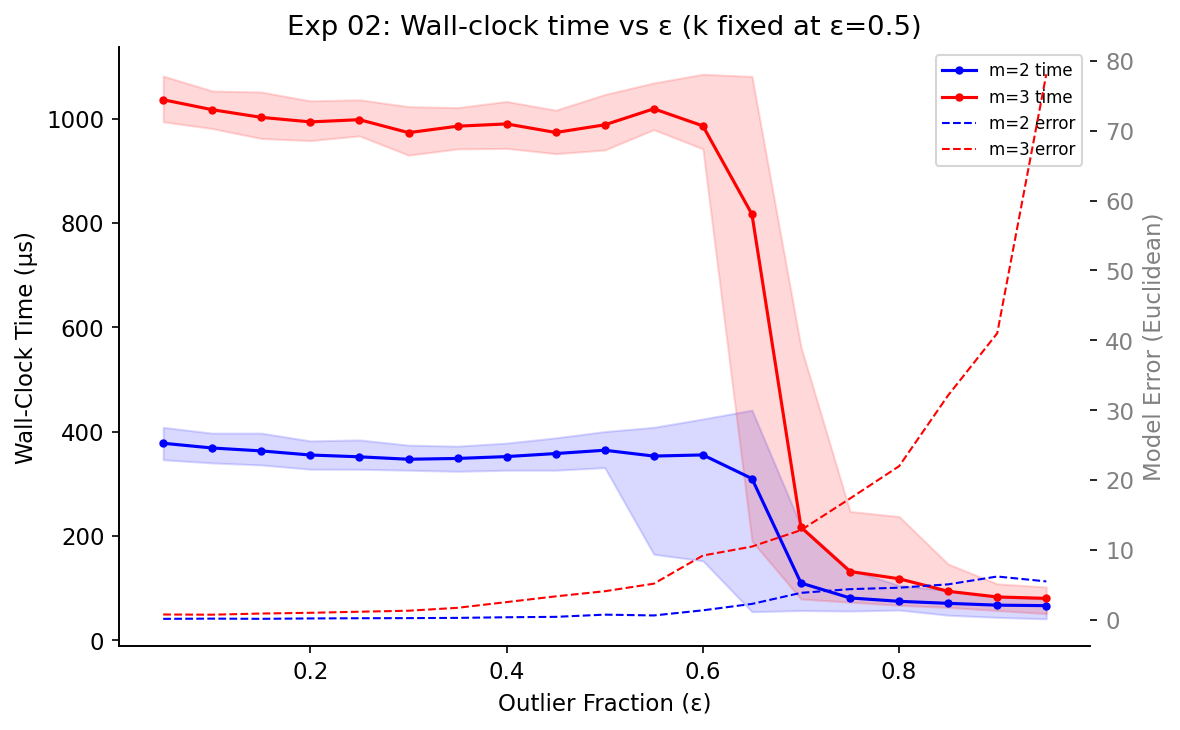

In [99]:
fig, ax1 = plt.subplots(figsize=(8, 5))
ax2 = ax1.twinx()

for m, color in [(2, "blue"), (3, "red")]:
    sub = df02[df02["Model Parameters (m)"] == m]
    grp = sub.groupby("Outlier Fraction (ε)")["Wall-Clock Time (μs)"]
    means = grp.mean()
    lower = grp.quantile(0.05)
    upper = grp.quantile(0.95)

    ax1.plot(means.index, means.values,
             color=color, marker="o", markersize=3, label=f"m={m} time")
    ax1.fill_between(means.index, lower, upper, alpha=0.15, color=color)

    grp2 = sub.groupby("Outlier Fraction (ε)")["Model Error (Euclidean)"]
    ax2.plot(grp2.mean().index, grp2.mean().values,
             color=color, linestyle="--", linewidth=1, label=f"m={m} error")

ax1.set_xlabel("Outlier Fraction (ε)")
ax1.set_ylabel("Wall-Clock Time (μs)")
ax2.set_ylabel("Model Error (Euclidean)", color="grey")
ax2.tick_params(axis="y", labelcolor="grey")
ax1.set_title("Exp 02: Wall-clock time vs ε (k fixed at ε=0.5)")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=8)

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/exp02_time_vs_epsilon.png", dpi=150)
plt.show()

### Observations
* Early stopping kicks in after eps = 0.5

In [101]:
df03 = pd.read_csv(f"{DATA_DIR}/exp03.csv")
df03.rename(columns=COL_NAMES, inplace=True)
df03.head()

,Run Index,Total Points (N),Outlier Fraction (ε),Expected Inliers (d),Model Parameters (m),Iterations Used (k),Inlier Threshold (t),t_multiplier,Repeat Number,Wall-Clock Time (μs),Model Error (Euclidean)
0,0,1000,0.5,500,2,17,0.25,0.5,0,286.0,0.666166
1,1,1000,0.5,500,2,17,0.25,0.5,1,258.0,0.550013
2,2,1000,0.5,500,2,17,0.25,0.5,2,267.0,1.283816
3,3,1000,0.5,500,2,17,0.25,0.5,3,286.0,0.793304
4,4,1000,0.5,500,2,17,0.25,0.5,4,267.0,1.458768


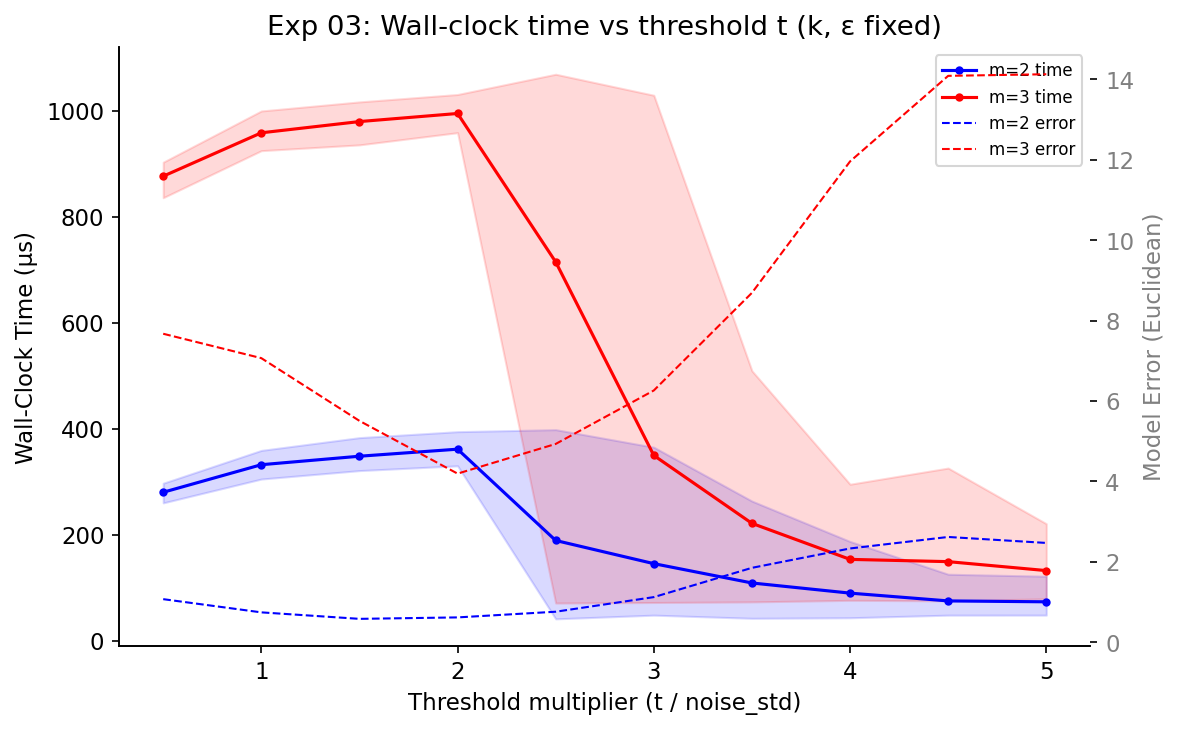

In [106]:
fig, ax1 = plt.subplots(figsize=(8, 5))
ax2 = ax1.twinx()

for m, color in [(2, "blue"), (3, "red")]:
    sub = df03[df03["Model Parameters (m)"] == m]
    grp = sub.groupby("t_multiplier")["Wall-Clock Time (μs)"]
    means = grp.mean()
    lower = grp.quantile(0.05)
    upper = grp.quantile(0.95)

    ax1.plot(means.index, means.values,
             color=color, marker="o", markersize=3, label=f"m={m} time")
    ax1.fill_between(means.index, lower, upper, alpha=0.15, color=color)

    grp2 = sub.groupby("t_multiplier")["Model Error (Euclidean)"]
    ax2.plot(grp2.mean().index, grp2.mean().values,
             color=color, linestyle="--", linewidth=1, label=f"m={m} error")

ax1.set_xlabel("Threshold multiplier (t / noise_std)")
ax1.set_ylabel("Wall-Clock Time (μs)")
ax2.set_ylabel("Model Error (Euclidean)", color="grey")
ax2.tick_params(axis="y", labelcolor="grey")
ax1.set_title("Exp 03: Wall-clock time vs threshold t (k, ε fixed)")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=8)

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/exp03_time_vs_threshold.png", dpi=150)
plt.show()

### Observation: 
* Since we have kept noise at 2, for small t up to 2, even true inliers may fall outside the threshold due to noise — so RANSAC struggles to find d inliers and runs many iterations before succeeding or exhausting k. That's the slow region.
* Beyond multiplier 2, the threshold is so wide that outliers start counting as inliers too, inflating the consensus set size past d quickly and triggering early stopping — hence the drop.

## Experiment 1 — How Does RANSAC Break Down as Outlier Fraction Increases?

Fix $k$ at the value computed for $\varepsilon = 0.5$. Vary $\varepsilon$ from 0.1 to 0.9.
Run for linear ($m=2$) and quadratic ($m=3$) models. `N` is 1000. Repeat `N_REPEATS` times.

In [4]:
df1 = pd.read_csv('results/exp1.csv').rename(columns=COL_NAMES)
df1.head()

,Run Index,Total Points (N),Outlier Fraction (ε),Expected Inliers (d),Model Parameters (m),Iterations Used (k),Inlier Threshold (t),Repeat Number,Wall-Clock Time (μs),Model Error (Euclidean)
0,0,1000,0.05,950,2,17,0.9992,0,397.0,0.112070
1,1,1000,0.05,950,2,17,1.0011,1,349.0,0.090577
2,2,1000,0.05,950,2,17,0.9663,2,390.0,0.190570
3,3,1000,0.05,950,2,17,0.9853,3,340.0,0.089918
4,4,1000,0.05,950,2,17,1.0075,4,392.0,0.075750


In [13]:
agg1 = (df1.groupby(['Model Parameters (m)', 'Outlier Fraction (ε)'])
           ['Model Error (Euclidean)']
           .agg(mean_error='mean', std_error='std', count='count')
           .reset_index())

In [14]:
# breakdown threshold — model error greater than twice noise std
BREAKDOWN_THRESHOLD = 2 * 0.5   # 2 * NOISE_STD

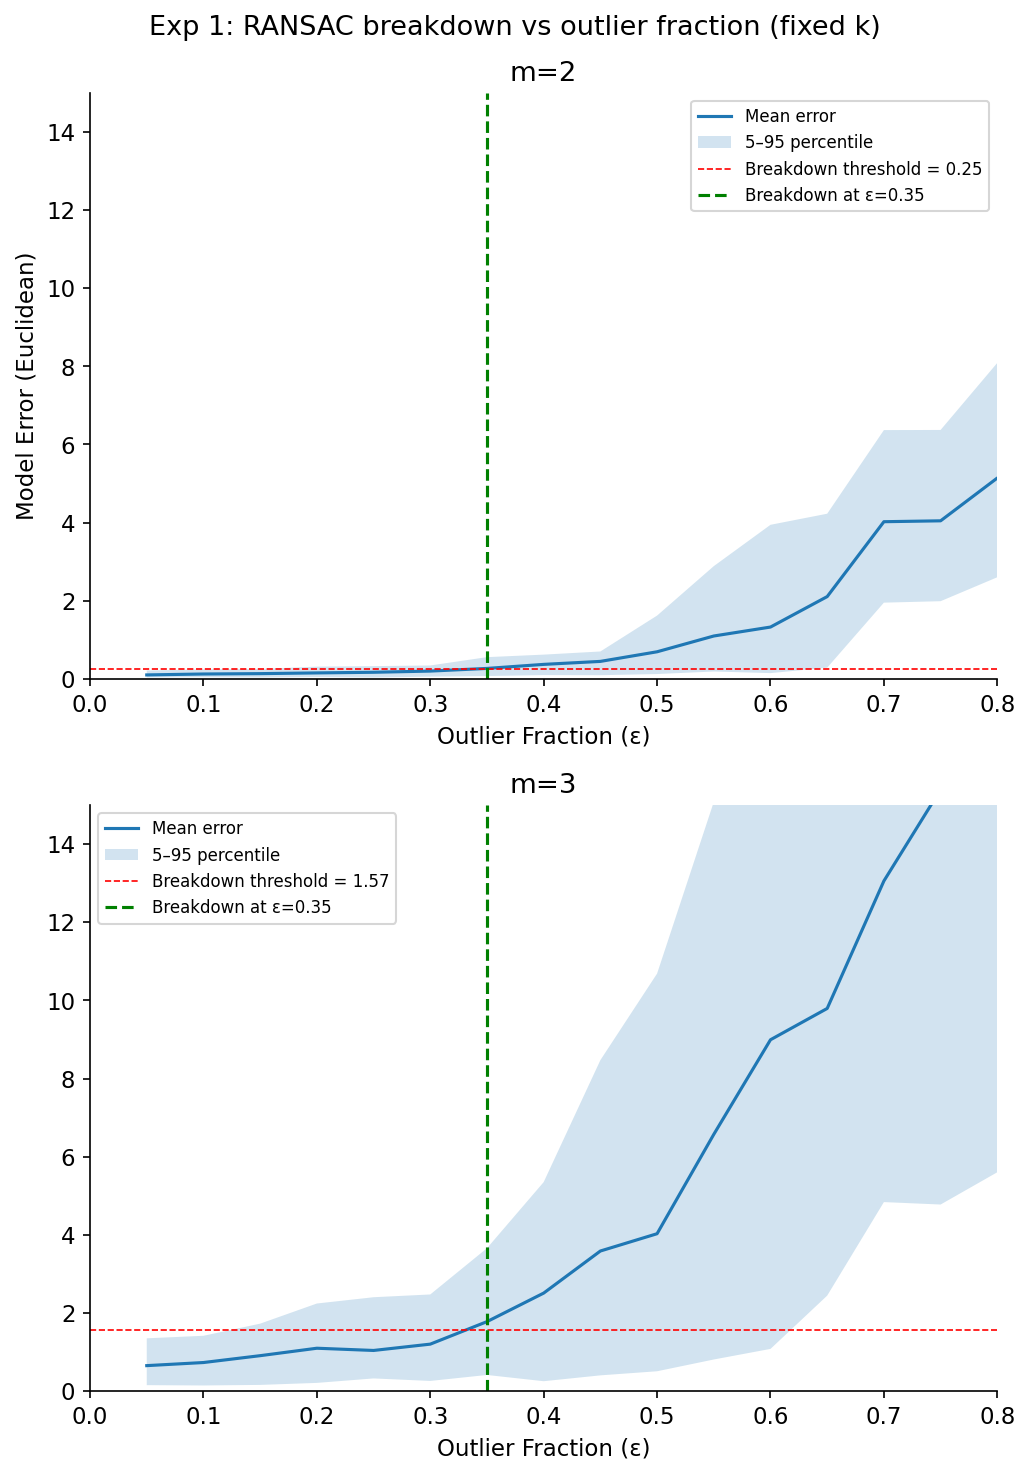

In [22]:
models = df1["Model Parameters (m)"].unique()

fig, axes = plt.subplots(len(models), 1, figsize=(7, 10))

for i, m in enumerate(models):
    ax  = axes[i]
    sub = df1[df1["Model Parameters (m)"] == m]
    grp = sub.groupby("Outlier Fraction (ε)")["Model Error (Euclidean)"]

    means = grp.mean()
    lower = grp.quantile(0.10)
    upper = grp.quantile(0.90)

    baseline_mean = means.iloc[0]
    baseline_std  = grp.std().iloc[0]
    threshold     = baseline_mean + 2 * baseline_std

    ax.plot(means.index, means.values, label="Mean error")
    ax.fill_between(means.index, lower, upper, alpha=0.2, label="5–95 percentile")
    ax.axhline(threshold, color="red", linestyle="--",
               linewidth=0.8, label=f"Breakdown threshold = {threshold:.2f}")

    breakdown_rows = means[means > threshold]
    if not breakdown_rows.empty:
        breakdown_eps = breakdown_rows.index[0]
        ax.axvline(x=breakdown_eps, color="green", linestyle="--",
                   label=f"Breakdown at ε={breakdown_eps:.2f}")

    ax.set_title(f"m={m}")
    ax.set_xlabel("Outlier Fraction (ε)")
    ax.set_xlim(0, 0.8)
    ax.set_ylim(0, 15)
    if i == 0:
        ax.set_ylabel("Model Error (Euclidean)")
    ax.legend(fontsize=8)

plt.suptitle("Exp 1: RANSAC breakdown vs outlier fraction (fixed k)",
             fontsize=13)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/exp1_outlier_fraction.png", dpi=150)
plt.show()

---
## Experiment 2 — At What Structural Bias Probability Does RANSAC Fail?

Fix $\varepsilon = 0.3$. Vary $p_r$ from 0.0 to 1.0 in steps of 0.1.
Three bias types: constant, linear, periodic. Linear and quadratic models. `N` is 1000. Repeat `N_REPEATS` times.

In [16]:
df2 = pd.read_csv('results/exp2.csv').rename(columns=COL_NAMES)
df2.head()

,Run Index,Total Points (N),Outlier Fraction (ε),Expected Inliers (d),Model Parameters (m),Iterations Used (k),Inlier Threshold (t),Bias Probability (pr),Bias Type,Repeat Number,Wall-Clock Time (μs),Model Error (Euclidean)
0,0,1000,0.1,900,2,17,0.9968,0.0,constant,0,390.0,0.179528
1,1,1000,0.1,900,2,17,0.9949,0.0,constant,1,364.0,0.052584
2,2,1000,0.1,900,2,17,0.9802,0.0,constant,2,353.0,0.341749
3,3,1000,0.1,900,2,17,1.0058,0.0,constant,3,354.0,0.226147
4,4,1000,0.1,900,2,17,0.9708,0.0,constant,4,338.0,0.153389


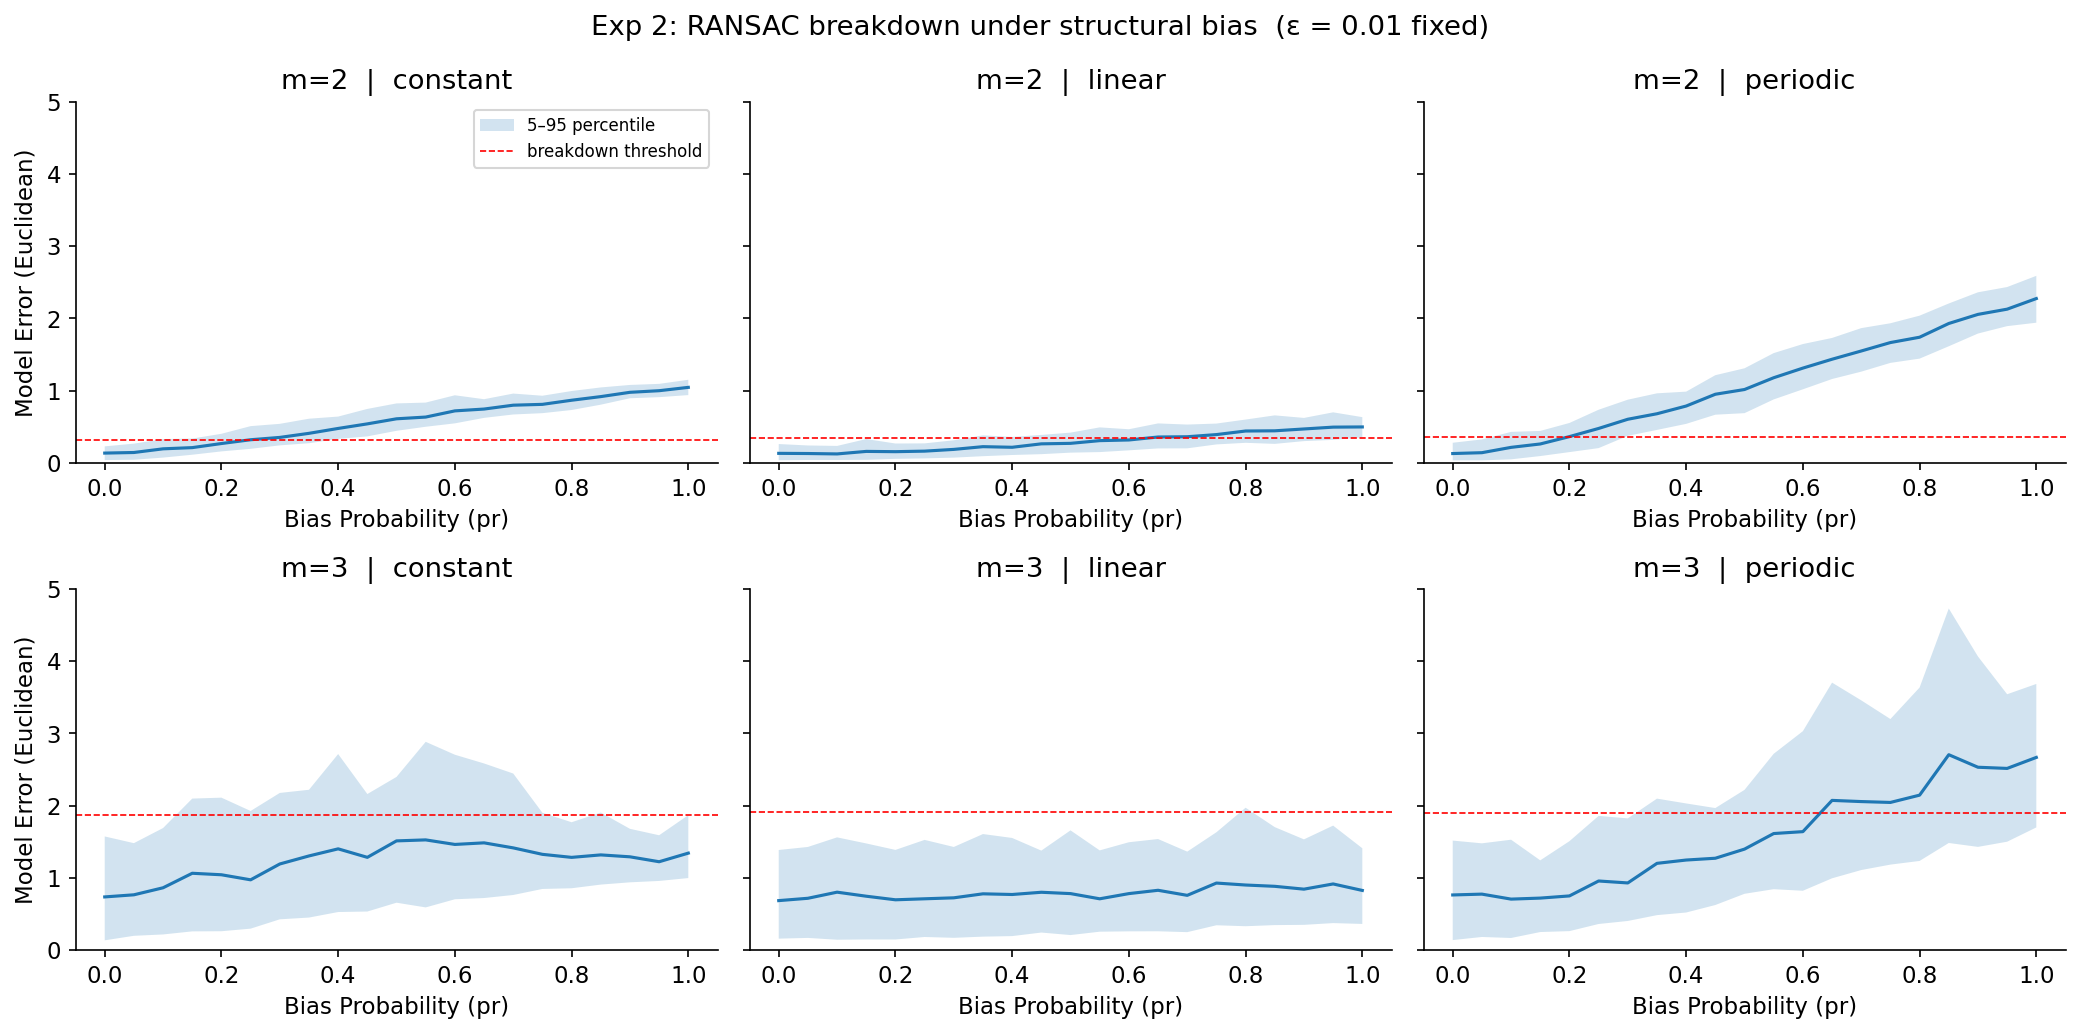

In [23]:
bias_types = df2["Bias Type"].unique()
models     = df2["Model Parameters (m)"].unique()

fig, axes = plt.subplots(len(models), len(bias_types),
                         figsize=(14, 7), sharey=True)

for i, m in enumerate(models):
    for j, bias in enumerate(bias_types):
        ax  = axes[i, j]
        sub = df2[(df2["Model Parameters (m)"] == m) &
                  (df2["Bias Type"] == bias)]
        grp = sub.groupby("Bias Probability (pr)")["Model Error (Euclidean)"]

        means = grp.mean()
        stds  = grp.std()
        lower = grp.quantile(0.10)
        upper = grp.quantile(0.90)

        baseline_mean = means.loc[0.0]
        baseline_std  = stds.loc[0.0]
        threshold     = baseline_mean + 2 * baseline_std

        ax.plot(means.index, means.values)
        ax.fill_between(means.index, lower, upper, alpha=0.2, label='5–95 percentile')
        ax.axhline(threshold, color='red', linestyle='--',
                   linewidth=0.8, label='breakdown threshold')

        ax.set_title(f"m={m}  |  {bias}")
        ax.set_xlabel("Bias Probability (pr)")
        ax.set_ylim(0, 5)
        if j == 0:
            ax.set_ylabel("Model Error (Euclidean)")
        if i == 0 and j == 0:
            ax.legend(fontsize=8)

plt.suptitle("Exp 2: RANSAC breakdown under structural bias  (ε = 0.01 fixed)")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/exp2.png", dpi=150)
plt.show()

### Observations:

Linear Model:
1. In presense of constant bias, RANSAC breaks down linear model recovery fairly low amount of bias at pr ~ 0.2.
2. In presense of linear bias, RANSAC can recover true model at modest bias with pr ~0.6.
3. In presence of periodic bias again, RANSAC breaksdown at low amounts of bias at pr ~0.2.

Quadratic Model:
1. In presense of constant and linear bias, there is no break-down.
2. In presence of periodic bias, RANSAC breaks down after modest amount of bias at pr ~0.6.

---
## Experiment 3 — At What Model Degree Does RANSAC Fail for a Budgeted or Fixed Iteration Count?

Fix $\varepsilon = 0.1$. Vary $m$ from 2 to 8 in steps of 1. Run twice for $k$ = 100 and $k$ = 1000. `N` is 1000. Repeat 100 times.


In [68]:
df3 = pd.read_csv('results/exp3.csv').rename(columns=COL_NAMES)
df3.head()

,Run Index,Total Points (N),Outlier Fraction (ε),Expected Inliers (d),Model Parameters (m),Iteration Budget (k),Iterations Required by Theory,Inlier Threshold (t),Repeat Number,Wall-Clock Time (μs),Model Error (Euclidean)
0,0,1000,0.5,500,3,100,35,1.0169,0,2793.0,2.385617
1,1,1000,0.5,500,3,100,35,1.0324,1,2796.0,1.213823
2,2,1000,0.5,500,3,100,35,1.0175,2,1801.0,0.522615
3,3,1000,0.5,500,3,100,35,1.0212,3,2768.0,2.725188
4,4,1000,0.5,500,3,100,35,0.9836,4,2744.0,1.976096


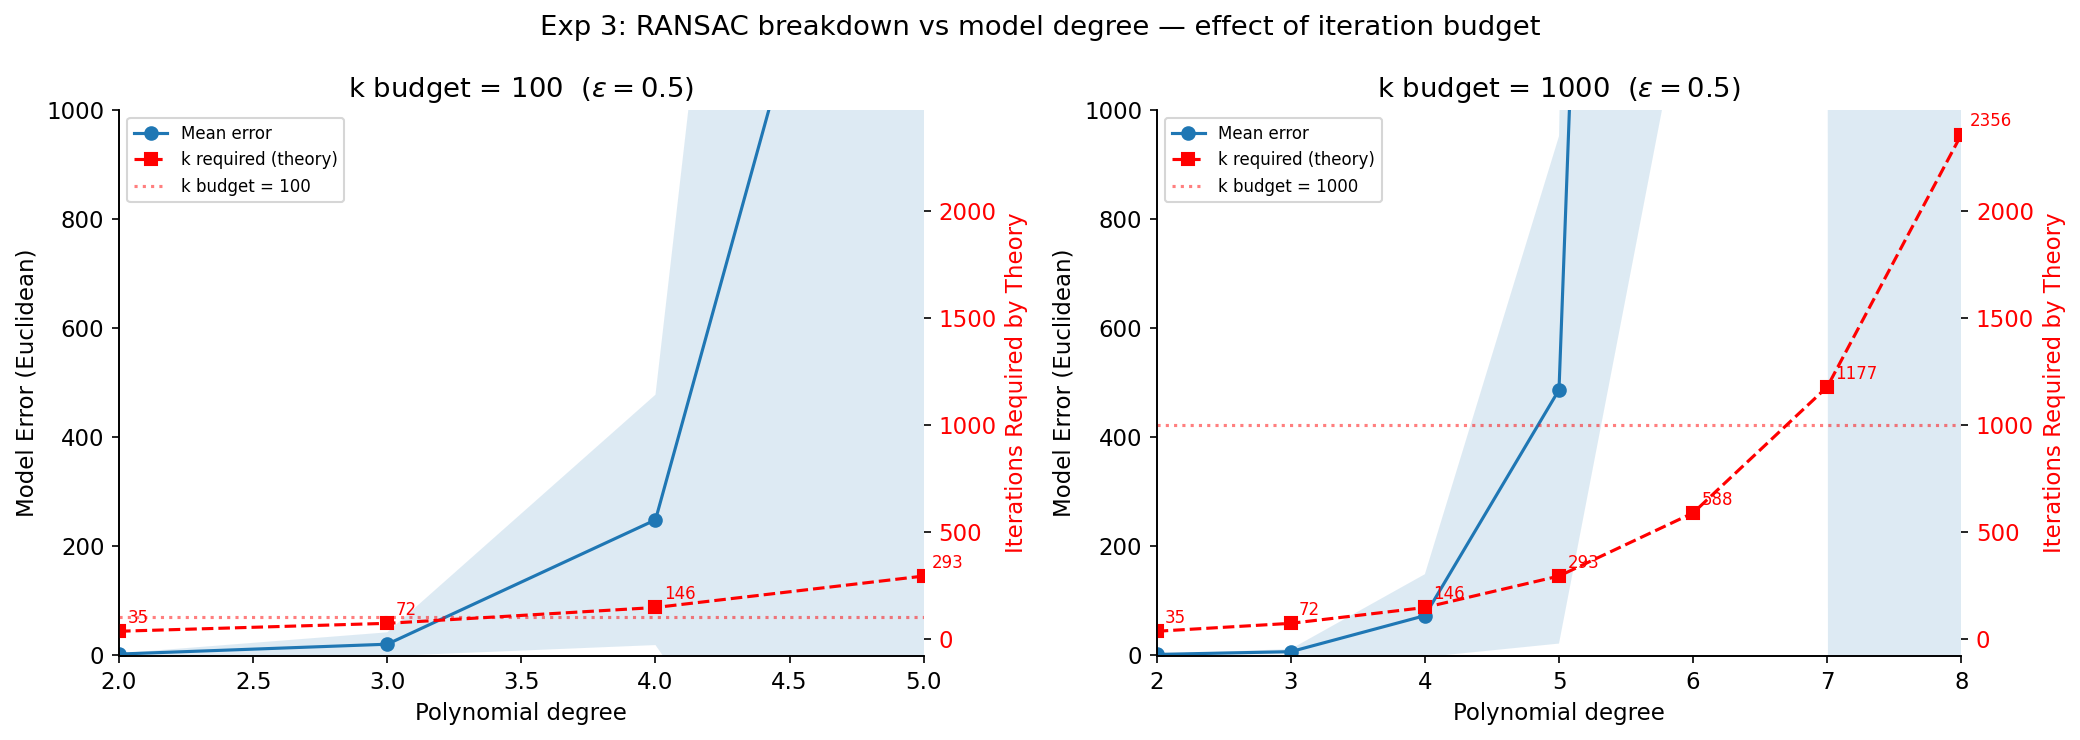

In [83]:
df3["degree"] = df3["Model Parameters (m)"] - 1
sub100  = df3[df3["Iteration Budget (k)"].astype(int) == 100]
sub1000 = df3[df3["Iteration Budget (k)"].astype(int) == 1000]

agg100  = (sub100.groupby("degree")["Model Error (Euclidean)"]
                  .agg(mean_error="mean", std_error="std")
                  .reset_index())
agg1000 = (sub1000.groupby("degree")["Model Error (Euclidean)"]
                   .agg(mean_error="mean", std_error="std")
                   .reset_index())

agg_theory = (sub100.groupby("degree")["Iterations Required by Theory"]
                     .first().reset_index())
fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(14, 5))
# fig, (ax_l, ax_r) = plt.subplots(2, 1, figsize=(7, 10))

for ax1, agg, k_budget in [(ax_l, agg100, 100), (ax_r, agg1000, 1000)]:
    ax2 = ax1.twinx()

    ax1.plot(agg["degree"], agg["mean_error"],
             marker="o", label="Mean error")
    ax1.fill_between(agg["degree"],
                     agg["mean_error"] - agg["std_error"],
                     agg["mean_error"] + agg["std_error"],
                     alpha=0.15)

    ax2.plot(agg_theory["degree"],
             agg_theory["Iterations Required by Theory"],
             marker="s", color="red", linestyle="--",
             label="k required (theory)")
    for _, row in agg_theory.iterrows():
        ax2.annotate(f"{int(row['Iterations Required by Theory'])}",
                     xy=(row["degree"], row["Iterations Required by Theory"]),
                     xytext=(4, 4), textcoords="offset points",
                     color="red", fontsize=8)
    ax2.axhline(k_budget, color="red", linestyle=":",
                alpha=0.5, label=f"k budget = {k_budget}")
    ax2.tick_params(axis='y', labelcolor='red')
    ax1.set_xlabel("Polynomial degree")
    ax1.set_ylabel("Model Error (Euclidean)")
    ax2.set_ylabel("Iterations Required by Theory", color="red")
    ax1.set_title(f"k budget = {k_budget}  ($\\varepsilon=0.5$)")
    ax1.set_ylim(-2, 1000)
    if k_budget == 100:
        ax1.set_xlim(2, 5)
    else:
        ax1.set_xlim(2, 8)
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2,
               loc="upper left", fontsize=8)
    #ax1.set_ylim(0, 10)

plt.suptitle("Exp 3: RANSAC breakdown vs model degree — effect of iteration budget")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/exp3_model_degree.png", dpi=150)
plt.show()
